# Đề 1: KNN phân loại Hoa Iris

## Yêu cầu bài toán

- Tải bộ dữ liệu Iris từ Scikit-Learn.
- Hiển thị mô tả ngắn gọn về dữ liệu.
- In ra tên các đặc trưng.
- Chia dữ liệu thành tập huấn luyện 75% và tập kiểm tra 25%.
- Chuẩn hóa dữ liệu bằng StandardScaler.
- Áp dụng thuật toán K-Nearest Neighbors với k = 5.
- Dự đoán trên tập kiểm tra.
- Tính Accuracy và F1-score.
- Vẽ ma trận nhầm lẫn.

## 1 : Goi thu vien:

In [20]:
import pandas as pd 
from sklearn.datasets import load_iris # bắt buộc phải gọi dữ liệu
from sklearn.model_selection import train_test_split # đối với phân loại bắt buộc phải có chia train test 
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay # bắt buộc phải có các chỉ só 
from sklearn.neighbors import KNeighborsClassifier # gọi mô hình KNN 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # Hàm này dùng để chuân hóa bắt buộc phải nhớ nha gái 

## 2: Tải bộ dữ liệu iris - và xem thông tin dữ liệu :

In [21]:
du_lieu =load_iris()
df = pd.DataFrame(du_lieu.data, columns= du_lieu.feature_names)
print("In 5 dong dau du lieu: \n", df.head(5))
print("XEM THONG TIN BO DU LIEU: \n", df.info())
print("Mô tả bộ dữ liệu : \n", df.describe())

In 5 dong dau du lieu: 
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
XEM THONG TIN BO DU LIEU: 
 None
Mô tả bộ dữ liệu : 
        sepal length (cm)  sepal w

## 3: Chia bộ dữ liệu train - test : 

In [22]:
X = du_lieu.data
y = du_lieu.target
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state= 42)
print("Chia train test thanh cong")

Chia train test thanh cong


Biến	    Ý nghĩa
x_train	    dữ liệu đầu vào dùng để huấn luyện
x_test	    dữ liệu đầu vào dùng để kiểm tra
y_train	    nhãn thật của tập huấn luyện
y_test	    nhãn thật của tập kiểm tra

## 4 : Chuan hoa du lieu : 

In [23]:
bo_chuan_hoa = StandardScaler()
x_train = bo_chuan_hoa.fit_transform(x_train)
x_test = bo_chuan_hoa.transform(x_test)

## 5: Tạo mô hình KNn va huấn luyên mô hình 

In [24]:
mo_hinh = KNeighborsClassifier(n_neighbors=5)
mo_hinh.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## 6: Dự đoán trên tập kiểm tra : 

In [25]:
du_doan = mo_hinh.predict(x_test)
du_doan

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0])

## 7: Tính Accuracy và F1-score

In [26]:
accuracy = accuracy_score(y_test, du_doan)
f1 = f1_score(y_test, du_doan, average="macro")
print("Gia tri cua accracy: ",accuracy)
print("Gia tri cua F1: ", f1)

Gia tri cua accracy:  1.0
Gia tri cua F1:  1.0


## 8: Toa ma tran nham lan 

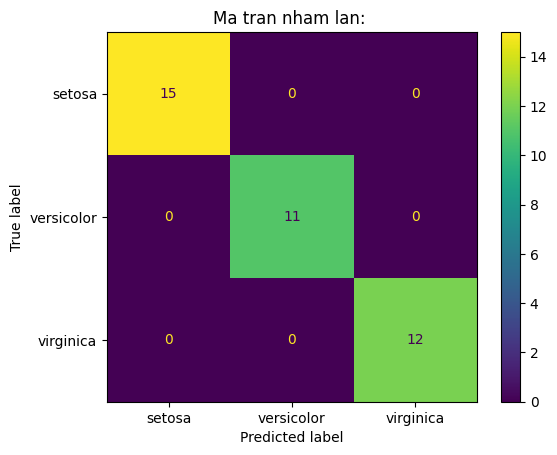

In [27]:
ma_tran = confusion_matrix(y_test, du_doan)
display = ConfusionMatrixDisplay(confusion_matrix=ma_tran, display_labels=du_lieu.target_names)
display.plot()
plt.title("Ma tran nham lan: ")
plt.show()

Mô hình KNN với k = 5 được sử dụng để phân loại bộ dữ liệu hoa Iris. 
Do bộ dữ liệu Iris có kích thước nhỏ, số đặc trưng ít và các lớp hoa tương đối rõ ràng, KNN có thể tận dụng khoảng cách giữa các mẫu để phân loại hiệu quả. 
Trước khi huấn luyện, dữ liệu được chuẩn hóa bằng StandardScaler nhằm tránh sự chênh lệch về thang đo giữa các đặc trưng. 
Kết quả ma trận nhầm lẫn cho thấy toàn bộ các mẫu kiểm tra đều được dự đoán đúng, không có mẫu nào bị phân loại nhầm. 
Vì vậy, mô hình đạt kết quả tốt trên tập kiểm tra.